<a href="https://colab.research.google.com/github/rozaxa/Artificial-Intelligence-Workshop-II/blob/Ray-Tune/MNIST_PyTorch_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Original Code here:
# https://github.com/pytorch/examples/blob/master/mnist/main.py

import argparse
import os
import tempfile

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from filelock import FileLock
from torchvision import datasets, transforms

import ray
from ray import train, tune
from ray.train import Checkpoint
from ray.tune.schedulers import AsyncHyperBandScheduler

# Change these values if you want the training to run quicker or slower.
EPOCH_SIZE = 512
TEST_SIZE = 256


class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 3, kernel_size=3)
        self.fc = nn.Linear(192, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 3))
        x = x.view(-1, 192)
        x = self.fc(x)
        return F.log_softmax(x, dim=1)


def train_func(model, optimizer, train_loader, device=None):
    device = device or torch.device("cpu")
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        if batch_idx * len(data) > EPOCH_SIZE:
            return
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()


def test_func(model, data_loader, device=None):
    device = device or torch.device("cpu")
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(data_loader):
            if batch_idx * len(data) > TEST_SIZE:
                break
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    return correct / total


def get_data_loaders(batch_size=64):
    mnist_transforms = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
    )

    # We add FileLock here because multiple workers will want to
    # download data, and this may cause overwrites since
    # DataLoader is not threadsafe.
    with FileLock(os.path.expanduser("~/data.lock")):
        train_loader = torch.utils.data.DataLoader(
            datasets.MNIST(
                "~/data", train=True, download=True, transform=mnist_transforms
            ),
            batch_size=batch_size,
            shuffle=True,
        )
        test_loader = torch.utils.data.DataLoader(
            datasets.MNIST(
                "~/data", train=False, download=True, transform=mnist_transforms
            ),
            batch_size=batch_size,
            shuffle=True,
        )
    return train_loader, test_loader


def train_mnist(config):
    should_checkpoint = config.get("should_checkpoint", False)
    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")
    train_loader, test_loader = get_data_loaders()
    model = ConvNet().to(device)

    optimizer = optim.SGD(
        model.parameters(), lr=config["lr"], momentum=config["momentum"]
    )

    while True:
        train_func(model, optimizer, train_loader, device)
        acc = test_func(model, test_loader, device)
        metrics = {"mean_accuracy": acc}

        # Report metrics (and possibly a checkpoint)
        if should_checkpoint:
            with tempfile.TemporaryDirectory() as tempdir:
                torch.save(model.state_dict(), os.path.join(tempdir, "model.pt"))
                train.report(metrics, checkpoint=Checkpoint.from_directory(tempdir))
        else:
            train.report(metrics)


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="PyTorch MNIST Example")
    parser.add_argument(
        "--cuda", action="store_true", default=False, help="Enables GPU training"
    )
    parser.add_argument(
        "--smoke-test", action="store_true", help="Finish quickly for testing"
    )
    args, _ = parser.parse_known_args()

    ray.init(num_cpus=2 if args.smoke_test else None)

    # for early stopping
    sched = AsyncHyperBandScheduler()

    resources_per_trial = {"cpu": 2, "gpu": int(args.cuda)}  # set this for GPUs
    tuner = tune.Tuner(
        tune.with_resources(train_mnist, resources=resources_per_trial),
        tune_config=tune.TuneConfig(
            metric="mean_accuracy",
            mode="max",
            scheduler=sched,
            num_samples=1 if args.smoke_test else 50,
        ),
        run_config=train.RunConfig(
            name="exp",
            stop={
                "mean_accuracy": 0.98,
                "training_iteration": 5 if args.smoke_test else 100,
            },
        ),
        param_space={
            "lr": tune.loguniform(1e-4, 1e-2),
            "momentum": tune.uniform(0.1, 0.9),
        },
    )
    results = tuner.fit()

    print("Best config is:", results.get_best_result().config)

    assert not results.errors

(train_mnist pid=8842) Downloading http://yann.lecun.com/exdb/mnist/train-images-idx3-ubyte.gz
(train_mnist pid=8842) Failed to download (trying next):
(train_mnist pid=8842) HTTP Error 403: Forbidden
(train_mnist pid=8842) 
(train_mnist pid=8842) Downloading https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz
(train_mnist pid=8842) Downloading https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz to /Users/agafelis/data/MNIST/raw/train-images-idx3-ubyte.gz


  0%|          | 0.00/9.91M [00:00<?, ?B/s]
  0%|          | 32.8k/9.91M [00:00<01:56, 84.7kB/s]
  1%|          | 65.5k/9.91M [00:00<01:56, 84.8kB/s]
  1%|          | 98.3k/9.91M [00:01<02:08, 76.6kB/s]
  1%|▏         | 131k/9.91M [00:01<01:58, 82.2kB/s] 
  2%|▏         | 164k/9.91M [00:01<01:53, 85.7kB/s]
  2%|▏         | 197k/9.91M [00:02<01:32, 105kB/s] 
  2%|▏         | 229k/9.91M [00:02<01:38, 98.5kB/s]
  3%|▎         | 262k/9.91M [00:02<01:41, 94.9kB/s]
  3%|▎         | 328k/9.91M [00:03<01:17, 124kB/s] 
  4%|▎         | 360k/9.91M [00:03<01:09, 137kB/s]
  4%|▍         | 393k/9.91M [00:03<01:18, 121kB/s]
  4%|▍         | 426k/9.91M [00:03<01:10, 135kB/s]
  5%|▍         | 459k/9.91M [00:04<01:03, 148kB/s]
  5%|▍         | 492k/9.91M [00:04<00:59, 157kB/s]
  5%|▌         | 524k/9.91M [00:04<00:57, 163kB/s]
  6%|▌         | 557k/9.91M [00:04<01:07, 139kB/s]
  6%|▋         | 623k/9.91M [00:04<00:49, 186kB/s]
  7%|▋         | 655k/9.91M [00:05<00:52, 178kB/s]
  7%|▋         | 688k/9.9

(train_mnist pid=8842) Extracting /Users/agafelis/data/MNIST/raw/train-images-idx3-ubyte.gz to /Users/agafelis/data/MNIST/raw
(train_mnist pid=8842) 
(train_mnist pid=8842) Downloading http://yann.lecun.com/exdb/mnist/train-labels-idx1-ubyte.gz
(train_mnist pid=8842) Failed to download (trying next):
(train_mnist pid=8842) HTTP Error 403: Forbidden
(train_mnist pid=8842) 
(train_mnist pid=8842) Downloading https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz
(train_mnist pid=8842) Downloading https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz to /Users/agafelis/data/MNIST/raw/train-labels-idx1-ubyte.gz


  0%|          | 0.00/28.9k [00:00<?, ?B/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 171kB/s]


(train_mnist pid=8842) Extracting /Users/agafelis/data/MNIST/raw/train-labels-idx1-ubyte.gz to /Users/agafelis/data/MNIST/raw
(train_mnist pid=8842) 
(train_mnist pid=8842) Downloading http://yann.lecun.com/exdb/mnist/t10k-images-idx3-ubyte.gz
(train_mnist pid=8842) Failed to download (trying next):
(train_mnist pid=8842) HTTP Error 403: Forbidden
(train_mnist pid=8842) 
(train_mnist pid=8842) Downloading https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz
(train_mnist pid=8842) Downloading https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz to /Users/agafelis/data/MNIST/raw/t10k-images-idx3-ubyte.gz


...

(train_mnist pid=8842) Extracting /Users/agafelis/data/MNIST/raw/t10k-images-idx3-ubyte.gz to /Users/agafelis/data/MNIST/raw
(train_mnist pid=8842) 
(train_mnist pid=8842) Downloading http://yann.lecun.com/exdb/mnist/t10k-labels-idx1-ubyte.gz
(train_mnist pid=8842) Failed to download (trying next):
(train_mnist pid=8842) HTTP Error 403: Forbidden
(train_mnist pid=8842) 
(train_mnist pid=8842) Downloading https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz
(train_mnist pid=8842) Downloading https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz to /Users/agafelis/data/MNIST/raw/t10k-labels-idx1-ubyte.gz


100%|██████████| 4.54k/4.54k [00:00<00:00, 5.19MB/s]


(train_mnist pid=8842) Extracting /Users/agafelis/data/MNIST/raw/t10k-labels-idx1-ubyte.gz to /Users/agafelis/data/MNIST/raw
(train_mnist pid=8842) 


(train_mnist pid=8842) /opt/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py:254: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
(train_mnist pid=8842)   warnings.warn('resource_tracker: There appear to be %d '
2024-11-17 12:53:11,991	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/Users/agafelis/ray_results/exp' in 0.0314s.
2024-11-17 12:53:12,001	INFO tune.py:1041 -- Total run time: 168.97 seconds (168.80 seconds for the tuning loop).


Best config is: {'lr': 0.007114837041517377, 'momentum': 0.6131534063042139}


In [ ]:
import os
from ray import train, tune
from ray.tune import ResultGrid

storage_path = "/tmp/ray_results"
exp_name = "tune_analyzing_results"

tuner = tune.Tuner(
    train_mnist, #ealier defined fun
    param_space={
        "lr": tune.loguniform(0.001, 0.1),
        "momentum": tune.grid_search([0.8, 0.9, 0.99]),
        "should_checkpoint": True,
    },
    run_config=train.RunConfig(
        name=exp_name,
        stop={"training_iteration": 100},
        checkpoint_config=train.CheckpointConfig(
            checkpoint_score_attribute="mean_accuracy",
            num_to_keep=5,
        ),
        storage_path=storage_path,
    ),
    tune_config=tune.TuneConfig(mode="max", metric="mean_accuracy", num_samples=3),
)

result_grid: ResultGrid = tuner.fit()

print("Najlepsza konfiguracja:", result_grid.get_best_result().config)

(train_mnist pid=9248) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/tmp/ray_results/tune_analyzing_results/train_mnist_8578d_00002_2_lr=0.0289,momentum=0.9900_2024-11-17_12-53-12/checkpoint_000000)
2024-11-17 12:53:21,201	WARNING experiment_state.py:206 -- Experiment state snapshotting has been triggered multiple times in the last 5.0 seconds and may become a bottleneck. A snapshot is forced if `CheckpointConfig(num_to_keep)` is set, and a trial has checkpointed >= `num_to_keep` times since the last snapshot.
You may want to consider increasing the `CheckpointConfig(num_to_keep)` or decreasing the frequency of saving checkpoints.
You can suppress this warning by setting the environment variable TUNE_WARN_EXCESSIVE_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a smaller value than the current threshold (5.0). Set it to 0 to completely suppress this warning.
2024-11-17 12:53:22,942	WARNING experiment_state.py:206 -- Experiment state snapshotting has been triggered m

Najlepsza konfiguracja: {'lr': 0.0065060418071856444, 'momentum': 0.9, 'should_checkpoint': True}


In [ ]:
if result_grid.errors:
    print("One of the trials failed!")
else:
    print("No errors!")

No errors!


In [ ]:
num_results = len(result_grid)
print("Number of results:", num_results)

Number of results: 9


In [ ]:
# Iterate over results
for i, result in enumerate(result_grid):
    if result.error:
        print(f"Trial #{i} had an error:", result.error)
        continue

    print(
        f"Trial #{i} finished successfully with a mean accuracy metric of:",
        result.metrics["mean_accuracy"]
    )

Trial #0 finished successfully with a mean accuracy metric of: 0.890625
Trial #1 finished successfully with a mean accuracy metric of: 0.9375
Trial #2 finished successfully with a mean accuracy metric of: 0.7
Trial #3 finished successfully with a mean accuracy metric of: 0.95
Trial #4 finished successfully with a mean accuracy metric of: 0.959375
Trial #5 finished successfully with a mean accuracy metric of: 0.88125
Trial #6 finished successfully with a mean accuracy metric of: 0.94375
Trial #7 finished successfully with a mean accuracy metric of: 0.934375
Trial #8 finished successfully with a mean accuracy metric of: 0.940625


In [ ]:
results_df = result_grid.get_dataframe()
results_df[["training_iteration", "mean_accuracy"]]

,training_iteration,mean_accuracy
0,100,0.890625
1,100,0.937500
2,100,0.700000
3,100,0.950000
4,100,0.959375
5,100,0.881250
6,100,0.943750
7,100,0.934375
8,100,0.940625


In [ ]:
print("Shortest training time:", results_df["time_total_s"].min())
print("Longest training time:", results_df["time_total_s"].max())

Shortest training time: 18.155622959136963
Longest training time: 64.37273144721985


In [ ]:
best_result_df = result_grid.get_dataframe(
    filter_metric="mean_accuracy", filter_mode="max"
)
best_result_df[["training_iteration", "mean_accuracy"]]

,training_iteration,mean_accuracy
0,98,0.950000
1,80,0.950000
2,7,0.862500
3,65,0.978125
4,92,0.978125
5,88,0.918750
6,74,0.959375
7,72,0.975000
8,98,0.959375


In [ ]:
from ray.train import Result

best_result: Result = result_grid.get_best_result()

# Get the result with the minimum `mean_accuracy`
worst_performing_result: Result = result_grid.get_best_result(
    metric="mean_accuracy", mode="min"
)

In [ ]:
best_result.config

{'lr': 0.0065060418071856444, 'momentum': 0.9, 'should_checkpoint': True}

In [ ]:
# Get the last reported set of metrics
best_result.metrics


{'mean_accuracy': 0.959375,
 'timestamp': 1731844516,
 'checkpoint_dir_name': 'checkpoint_000099',
 'should_checkpoint': True,
 'done': True,
 'training_iteration': 100,
 'trial_id': '8578d_00004',
 'date': '2024-11-17_12-55-16',
 'time_this_iter_s': 0.4254279136657715,
 'time_total_s': 64.37273144721985,
 'pid': 9326,
 'hostname': 'Mac.lan',
 'node_ip': '127.0.0.1',
 'config': {'lr': 0.0065060418071856444,
  'momentum': 0.9,
  'should_checkpoint': True},
 'time_since_restore': 64.37273144721985,
 'iterations_since_restore': 100,
 'experiment_tag': '4_lr=0.0065,momentum=0.9000'}

In [ ]:
result_df = best_result.metrics_dataframe
result_df[["training_iteration", "mean_accuracy", "time_total_s"]]

,training_iteration,mean_accuracy,time_total_s
0,1,0.150000,1.124536
1,2,0.278125,2.830898
2,3,0.346875,3.328984
3,4,0.440625,3.760034
4,5,0.656250,4.325948
...,...,...,...
95,96,0.934375,61.928451
96,97,0.959375,62.500210
97,98,0.965625,63.430600
98,99,0.962500,63.947304


### Plotting

<Axes: xlabel='training_iteration'>

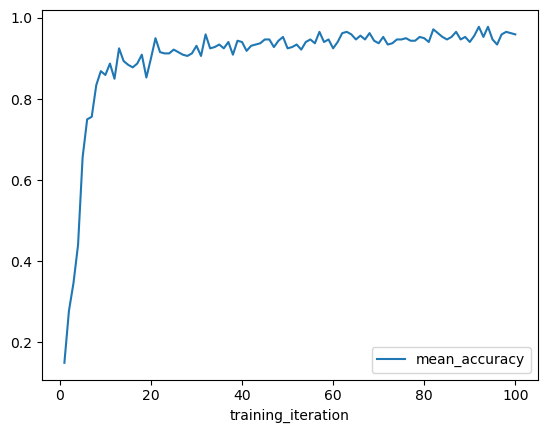

In [ ]:
best_result.metrics_dataframe.plot("training_iteration", "mean_accuracy")

Text(0, 0.5, 'Mean Test Accuracy')

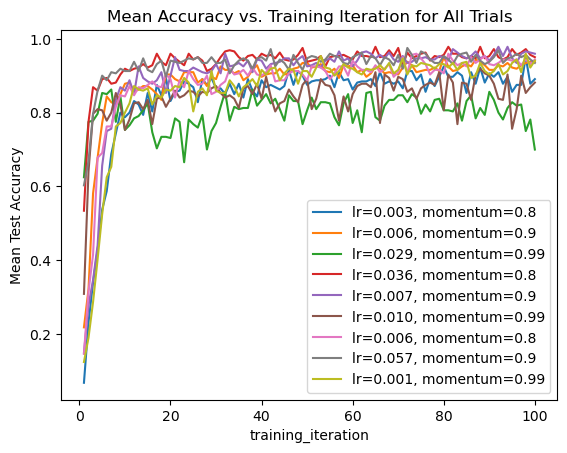

In [ ]:
ax = None
for result in result_grid:
    label = f"lr={result.config['lr']:.3f}, momentum={result.config['momentum']}"
    if ax is None:
        ax = result.metrics_dataframe.plot("training_iteration", "mean_accuracy", label=label)
    else:
        result.metrics_dataframe.plot("training_iteration", "mean_accuracy", ax=ax, label=label)
ax.set_title("Mean Accuracy vs. Training Iteration for All Trials")
ax.set_ylabel("Mean Test Accuracy")

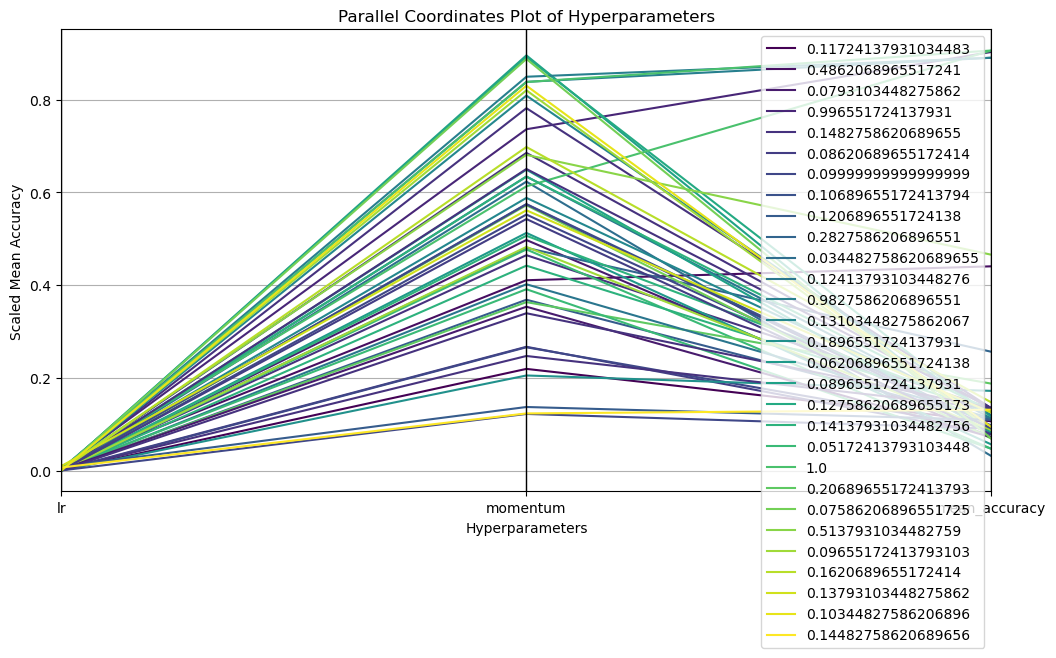

In [ ]:
from pandas.plotting import parallel_coordinates

df = pd.DataFrame(data)
df["mean_accuracy_scaled"] = df["mean_accuracy"] / df["mean_accuracy"].max()

plt.figure(figsize=(12, 6))
parallel_coordinates(df, class_column="mean_accuracy_scaled", colormap="viridis")
plt.title("Parallel Coordinates Plot of Hyperparameters")
plt.xlabel("Hyperparameters")
plt.ylabel("Scaled Mean Accuracy")
plt.show()


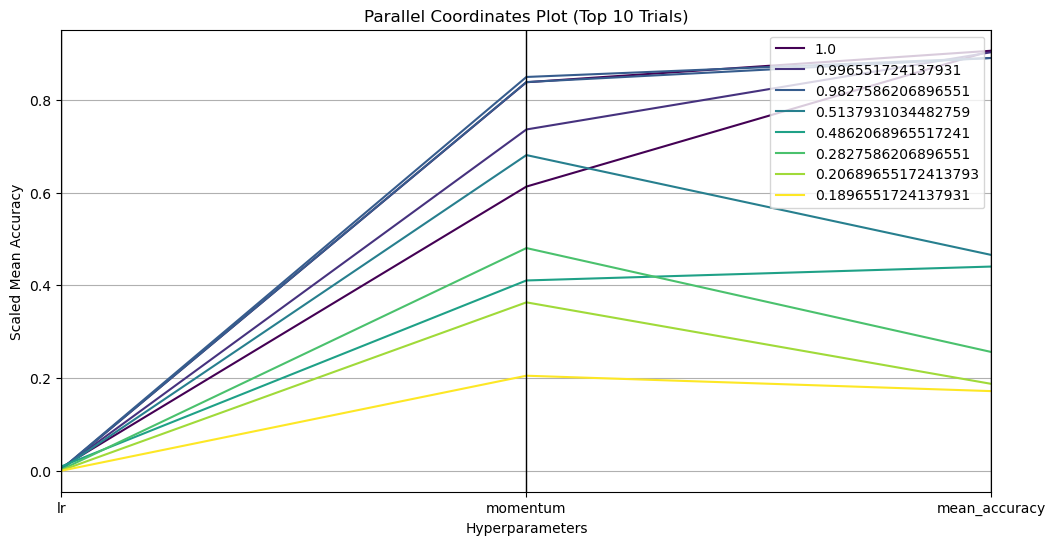

In [ ]:
df = pd.DataFrame(data)
df["mean_accuracy_scaled"] = df["mean_accuracy"] / df["mean_accuracy"].max()
df_top = df.nlargest(10, "mean_accuracy_scaled")

plt.figure(figsize=(12, 6))
parallel_coordinates(df_top, class_column="mean_accuracy_scaled", colormap="viridis")
plt.title("Parallel Coordinates Plot (Top 10 Trials)")
plt.xlabel("Hyperparameters")
plt.ylabel("Scaled Mean Accuracy")
plt.grid(True)
plt.show()



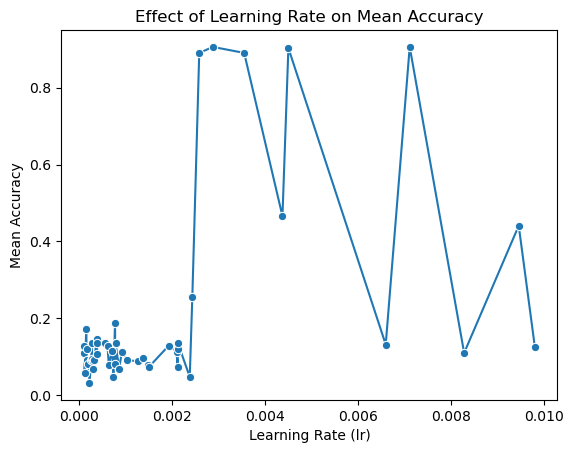

In [ ]:
sns.lineplot(x="lr", y="mean_accuracy", data=df, marker="o")
plt.title("Effect of Learning Rate on Mean Accuracy")
plt.xlabel("Learning Rate (lr)")
plt.ylabel("Mean Accuracy")
plt.show()


In [ ]:
import torch

from ray.tune.examples.mnist_pytorch import ConvNet, get_data_loaders

model = ConvNet()

with best_result.checkpoint.as_directory() as checkpoint_dir:
    # The model state dict was saved under `model.pt` by the training function
    # imported from `ray.tune.examples.mnist_pytorch`
    model.load_state_dict(torch.load(os.path.join(checkpoint_dir, "model.pt")))

/var/folders/0c/j_4gch9s4678hmgw2mdttz2m0000gn/T/ipykernel_8800/3006035957.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join

Predicted Class = 7


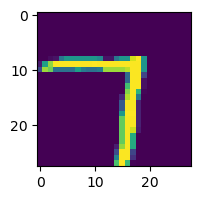

In [ ]:
import matplotlib.pyplot as plt

_, test_loader = get_data_loaders()
test_img = next(iter(test_loader))[0][0]

predicted_class = torch.argmax(model(test_img)).item()
print("Predicted Class =", predicted_class)

# Need to reshape to (batch_size, channels, width, height)
test_img = test_img.numpy().reshape((1, 1, 28, 28))
plt.figure(figsize=(2, 2))
plt.imshow(test_img.reshape((28, 28)))